#### One common mistake most of us commit is just by seeing the percentage of missing values in the column we just drop them. It is important to analyse why the value is missing or what does the missing value imply. It is always better to read the data description fully and have an idea on what each attribute means.

#### Let's analyse every missing attribute!

In [1]:
import numpy as np 
import pandas as pd 
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
%matplotlib inline
data = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
missing_columns = [col for col in data.columns if data[col].isnull().any()]
total = data.isnull().sum().sort_values(ascending=False)
percent = ((data.isnull().sum()/data.isnull().count())*100).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(len(missing_columns))

,Total,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageCond,81,5.547945
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


#### The table above shows that 99% of poolQC values are missing, which would tempt us to drop the column but from the data description we could notice that 'NA' in poolQC implies **No pool** which would be an important attribute when it comes to house pricing as houses with pool could be more costlier than houses with no pool.
#### Similarly 'NA' in attributes like MiscFeature, Alley, FirePlace, Garage, etc. means that particular feature is not present in the house which may affect the price.



In [2]:
data['PoolQC'].fillna("none", inplace = True)

#### LotFrontage has missing values which should be imputed

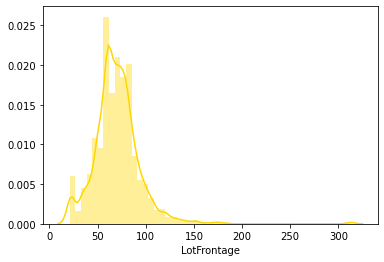

In [3]:
sns.distplot(data['LotFrontage'],color='#FFD700')

Imputing with mean value

In [4]:
data['LotFrontage'].fillna(data.LotFrontage.mean(), inplace = True)